$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Professor:}$ Cristiano Fernandes   
$ \textbf{Data:}$ 22 de Abril de 2026   

$ \textbf{Estudo Orientado - 2026.1}$

In [8]:
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, t, genpareto, genextreme, chi2, gamma, uniform, expon, gaussian_kde
import numdifftools as nd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from statsmodels.tsa.stattools import acf, pacf
from naveau_model import NaveauModelI as naveau

In [2]:
rng = np.random.default_rng(seed=4)

# Simulação Bernoulli-Gamma

## Probabilidade de chuva fixa
$$ 
\begin{align}
    f(y_t|y_{t-1}) &= (1-\pi)*(1-I_{y_t>0}) + \pi*g(y_t|y_{t-1})*I_{y_t>0}, \quad onde \\
    g(y_t|y_{t-1}) &\sim \text{Gamma}(\alpha, \theta) \\
\end{align}
$$ 

In [3]:
pi_list = [0.5, 0.6, 0.7, 0.8]
shape_list = [0.5,1,2]

theta = 10 # escala
dates = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
T = len(dates)

results = {}
for alpha in shape_list:
    df_sim = pd.DataFrame({'date': dates}).set_index('date')
    
    for pi in pi_list:
        gamma_points = rng.gamma(shape=alpha, scale=theta, size=T)
        bernoulli_points = rng.binomial(n=1, p=pi, size=T)
        simulated_points = bernoulli_points * gamma_points
        df_sim[f'{pi}'] = simulated_points
    
    results[f'{alpha}'] = df_sim
print('Dados simulados com {} observações de {} a {}'.format(
    T, dates[0].strftime('%b %Y'), dates[-1].strftime('%b %Y'))
     )

Dados simulados com 2192 observações de Jan 2020 a Dec 2025


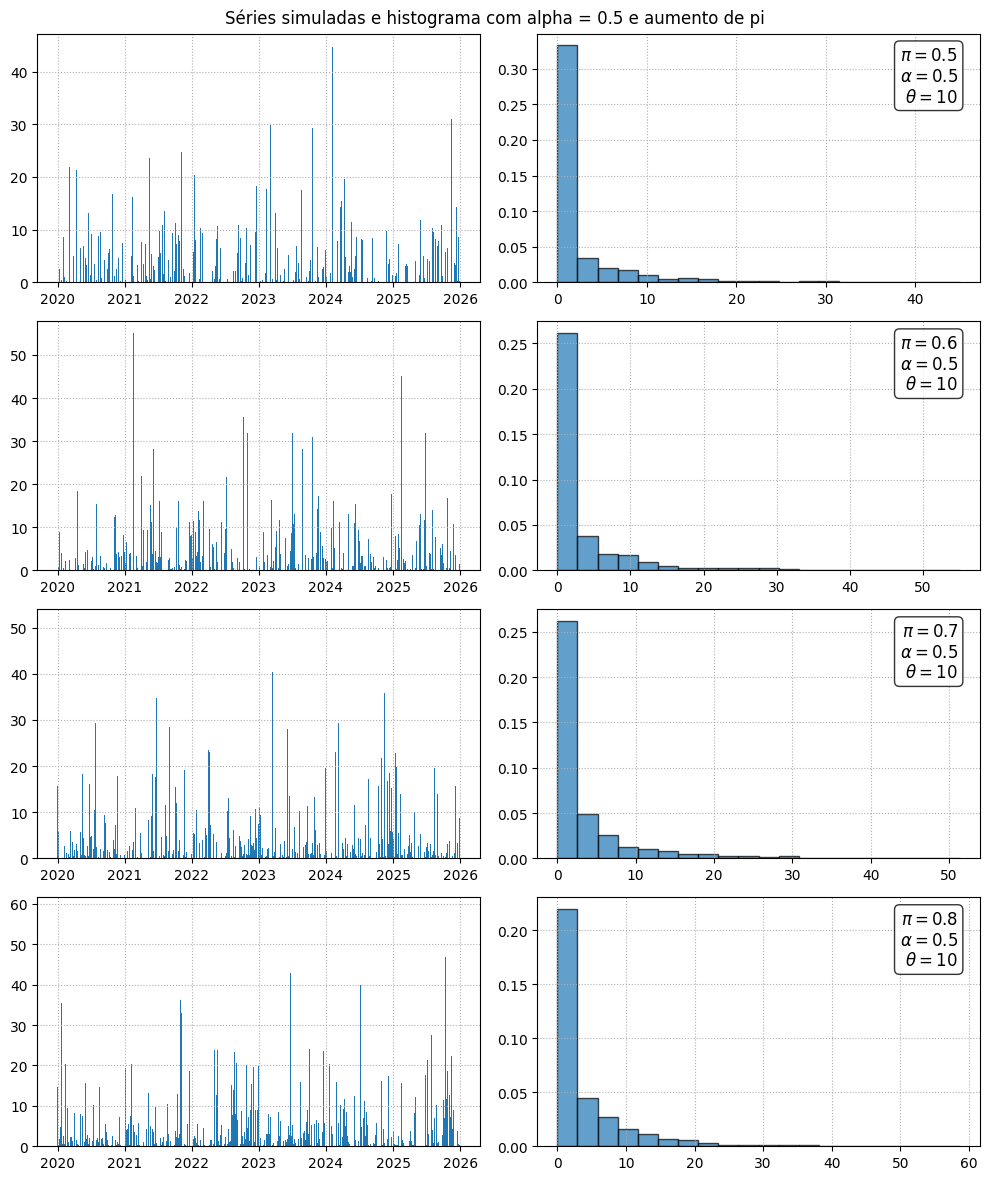

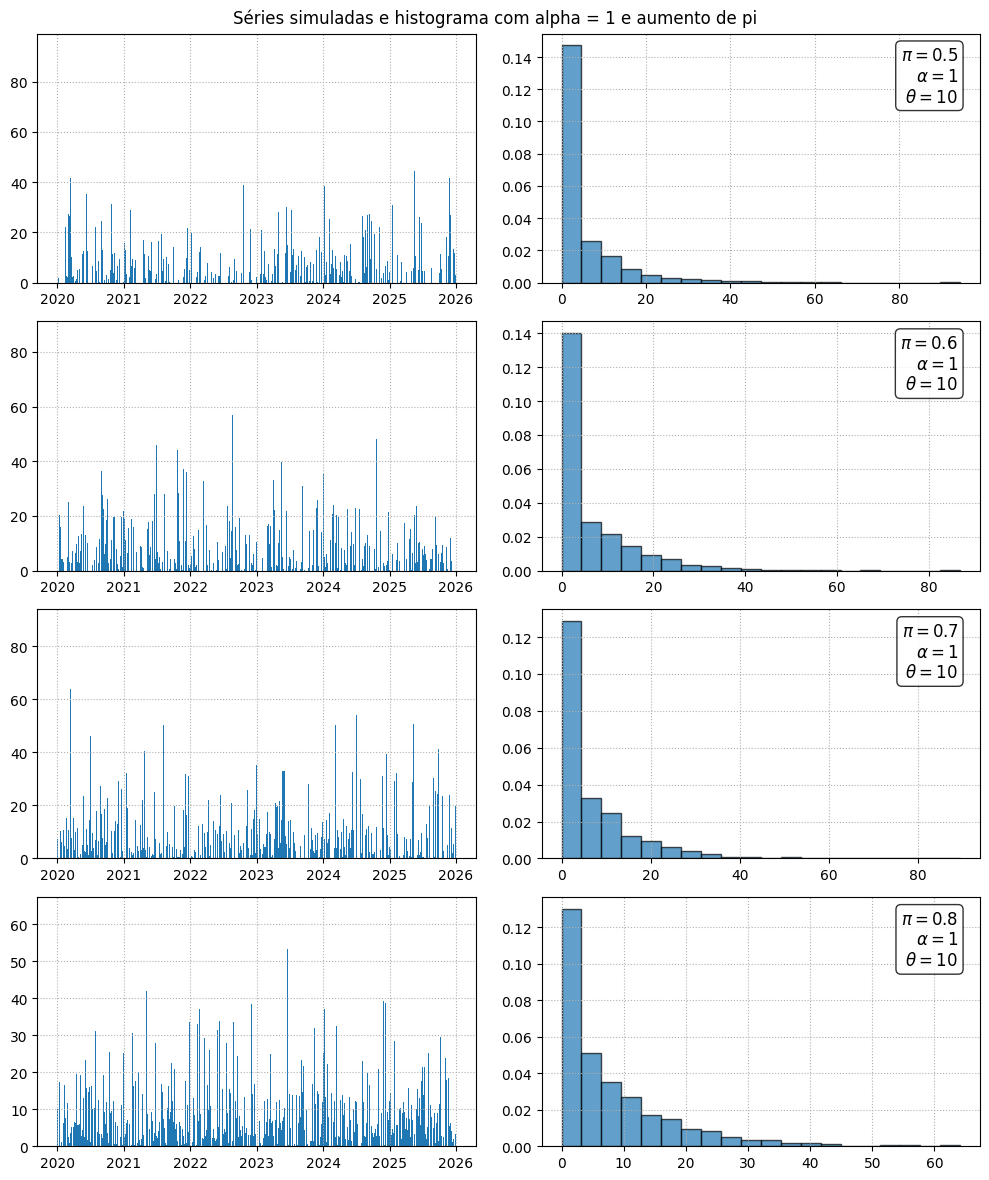

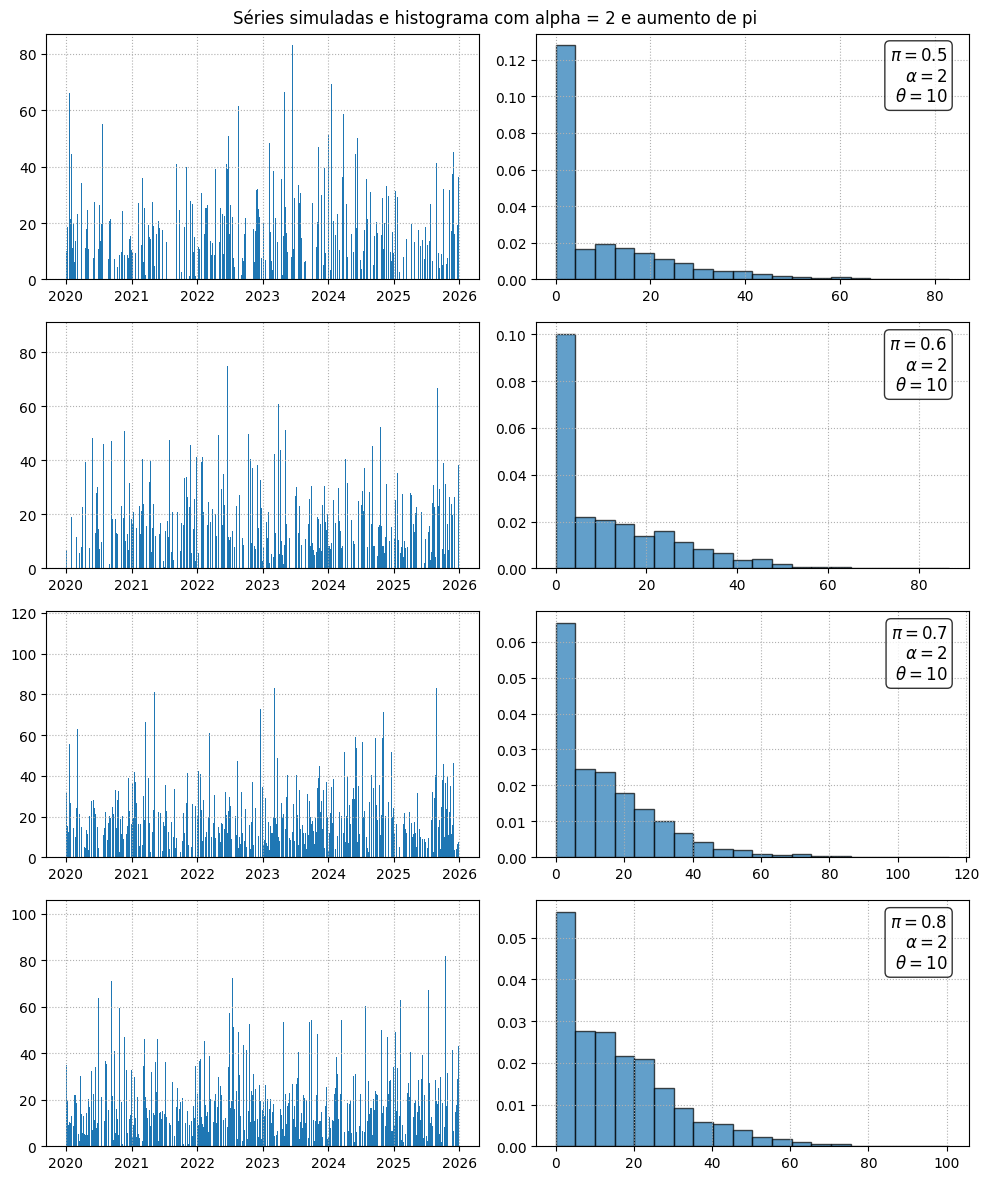

In [4]:
for alpha in shape_list:

    fig, ax = plt.subplots(len(pi_list),2,figsize=(10,12))
    
    for i in range(len(pi_list)):
        pi = pi_list[i]
        df_plot = results[f'{alpha}'][f'{pi}']
        textstr = f'$\pi={pi}$\n$\\alpha={alpha}$\n$\\theta={theta}$'
        
        ax[i][0].bar(df_plot.index, df_plot, width=1)
        ax[i][0].grid(axis='both', linestyle=':')
                
        ax[i][1].hist(df_plot, bins=20, density=True, alpha=0.7, edgecolor='black')
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        ax[i][1].text(0.95, 0.95, textstr, transform=ax[i][1].transAxes, fontsize=12,
                   verticalalignment='top', horizontalalignment='right', bbox=props)
        ax[i][1].grid(axis='both', linestyle=':')
    
    fig.suptitle('Séries simuladas e histograma com alpha = {} e aumento de pi'.format(alpha))
    fig.tight_layout()
    plt.show()

In [5]:
pi_list = [0.7]
shape_list = [0.5,1,2]

# theta = 10 # escala
dates = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
T = len(dates)

results = {}
for alpha in shape_list:
    df_sim = pd.DataFrame({'date': dates}).set_index('date')
    
    for pi in pi_list:
        gamma_points = rng.gamma(shape=alpha, scale=10/alpha, size=T)
        bernoulli_points = rng.binomial(n=1, p=pi, size=T)
        simulated_points = bernoulli_points * gamma_points
        df_sim[f'{pi}'] = simulated_points
    
    results[f'{alpha}'] = df_sim
print('Dados simulados com {} observações de {} a {}'.format(
    T, dates[0].strftime('%b %Y'), dates[-1].strftime('%b %Y'))
     )

Dados simulados com 2192 observações de Jan 2020 a Dec 2025


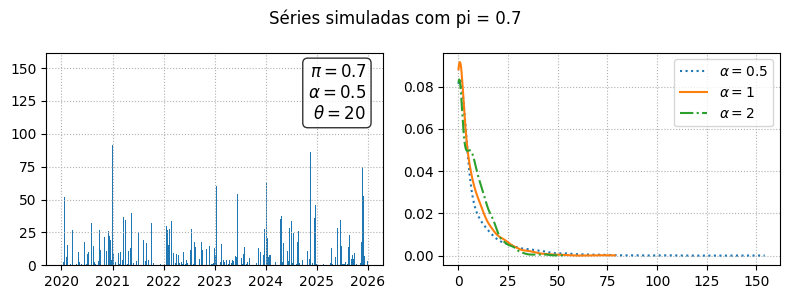

In [16]:
fig, ax = plt.subplots(len(pi_list),2,figsize=(8,3))

i=0
alpha = shape_list[i]
pi = pi_list[i]
df_plot = results[f'{alpha}'][f'{pi}']
textstr = f'$\pi={pi}$\n$\\alpha={alpha}$\n$\\theta={10/alpha:.0f}$'

ax[0].bar(df_plot.index, df_plot, width=1)
ax[0].grid(axis='both', linestyle=':')
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax[0].text(0.95, 0.95, textstr, transform=ax[0].transAxes, fontsize=12,
           verticalalignment='top', horizontalalignment='right', bbox=props)


ls = [':','-','-.']
for alpha in shape_list:
    df_plot = results[f'{alpha}'][f'{pi}']
    x = np.linspace(0, df_plot.max(), 300)
    kde = gaussian_kde(df_plot)
    ax[1].plot(x, kde(x), label=fr'$\alpha={alpha}$', linestyle=ls[i])
    i+=1

ax[1].grid(axis='both', linestyle=':')
ax[1].legend()
    
fig.suptitle('Séries simuladas com pi = {}'.format(pi))
fig.tight_layout()
plt.show()

## Probabilidade de chuva sazonal
$$ 
\begin{align}
    f(y_t|y_{t-1}) &= (1-\pi_t)*(1-I_{y_t>0}) + \pi_t*g(y_t|y_{t-1})*I_{y_t>0}, \quad onde \\
    g(y_t|y_{t-1}) &\sim \text{Gamma}(\alpha, \theta) \\
\end{align}
$$ 

In [5]:
def calculate_pi(date):
    day_of_year = date.dayofyear
    if 335 <= day_of_year or day_of_year <= 59:  # Dezembro a Fevereiro
        return 0.8  # pico de chuva
    elif 60 <= day_of_year <= 151:  # Março a Maio
        return 0.5  # transição
    elif 152 <= day_of_year <= 243:  # Junho a Agosto
        return 0.2  # período seco
    else:  # Setembro a Novembro
        return 0.4  # retomada da chuva

In [6]:
alpha = 2
theta = 10 # escala
dates = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
T = len(dates)
pi_t = [calculate_pi(t) for t in dates]

df_sim = pd.DataFrame({'date': dates}).set_index('date')
bernoulli_points = rng.binomial(n=1, p=pi_t)
gamma_points = rng.gamma(shape=alpha, scale=theta, size=T)
df_sim['seasonal'] = bernoulli_points * gamma_points

print('Dados simulados com {} observações de {} a {}'.format(
    T, dates[0].strftime('%b %Y'), dates[-1].strftime('%b %Y'))
     )

Dados simulados com 2192 observações de Jan 2020 a Dec 2025


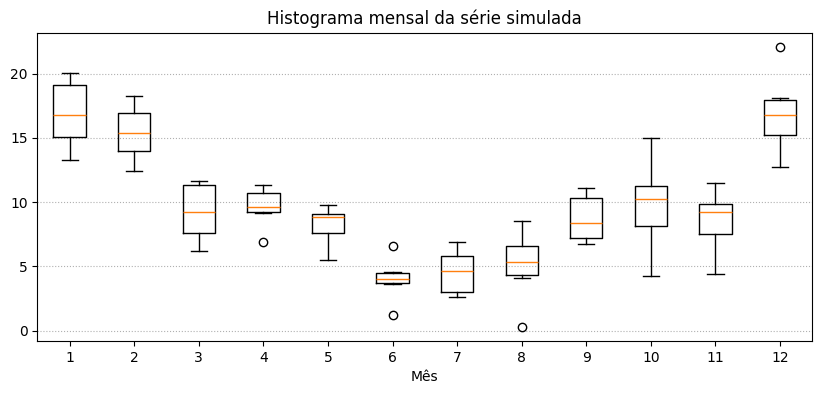

In [7]:
fig, ax = plt.subplots(figsize=(10,4))
plot_data = (df_sim
    .pivot_table(columns=df_sim.index.month, index=df_sim.index.year, values='seasonal')
    .dropna()
)
ax.boxplot(plot_data)
ax.set_xlabel('Mês')
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma mensal da série simulada')
plt.show()

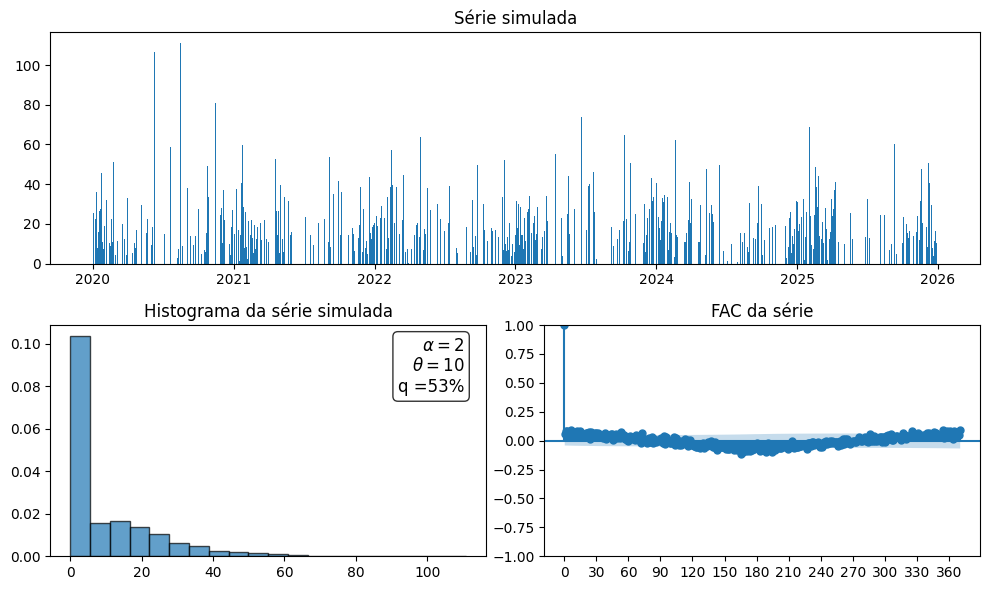

In [8]:
series = df_sim['seasonal']
q_zeros = (series == 0).sum() / len(df_sim)
textstr = f'$\\alpha={alpha}$\n$\\theta={theta}$\nq ={q_zeros:.0%}'

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, :])
ax0.bar(df_sim.index, df_sim['seasonal'], width=1)
ax0.set_title('Série simulada')

ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(df_sim, bins=20, density=True, alpha=0.7, edgecolor='black')
ax1.set_title('Histograma da série simulada')
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
           verticalalignment='top', horizontalalignment='right', bbox=props)

ax2 = fig.add_subplot(gs[1, 1])
lags=370
plot_acf(series.dropna(),lags=lags, ax=ax2, title=f'FAC da série')
ax2.set_xticks(np.arange(0, lags+1, 30))
ax2.set_xticklabels(np.arange(0, lags+1, 30))

fig.tight_layout()
plt.show()

In [9]:
print('Autocorrelação nos últimos lags:')
acf_vals = acf(series, nlags=370, fft=True)
acf_vals[364:]

Autocorrelação nos últimos lags:


array([0.0154574 , 0.08339189, 0.05844385, 0.06538939, 0.07809923,
       0.04542776, 0.09100508])

## Intensidade de chuva sazonal
$$ 
\begin{align}
    f(y_t|y_{t-1}) &= (1-\pi)*(1-I_{y_t>0}) + \pi*g(y_t|y_{t-1})*I_{y_t>0}, \quad onde \\
    g(y_t|y_{t-1}) &\sim \text{Gamma}(\alpha, \theta_t) \\
    E[y_t|y_{t-1}] &= \alpha \,\theta_t = \mu + A \sin\left(\frac{2\pi t}{365}\right)
\end{align}
$$ 

In [10]:
def calculate_lambda(date):
    t = date.dayofyear   
    mu = 10      # média anual (mm)
    A = 15        # amplitude
    t0 = 289     # alinha pico no verão (jan)
    lamb = mu + A * np.sin(2 * np.pi * (t) / 365)  
    return max(lamb, 0.1) # garantia numérica (evita valores muito pequenos)

In [11]:
pi = 0.6
alpha=2
dates = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
T = len(dates)
lamb_t = np.array([calculate_lambda(d) for d in dates])
theta_t = lamb_t / alpha # escala


df_sim = pd.DataFrame({'date': dates}).set_index('date')
bernoulli_points = rng.binomial(n=1, p=pi, size=T)
gamma_points = rng.gamma(shape=alpha, scale=theta_t)
df_sim['seasonal'] = bernoulli_points * gamma_points

print('Dados simulados com {} observações de {} a {}'.format(
    T, dates[0].strftime('%b %Y'), dates[-1].strftime('%b %Y'))
     )

Dados simulados com 2192 observações de Jan 2020 a Dec 2025


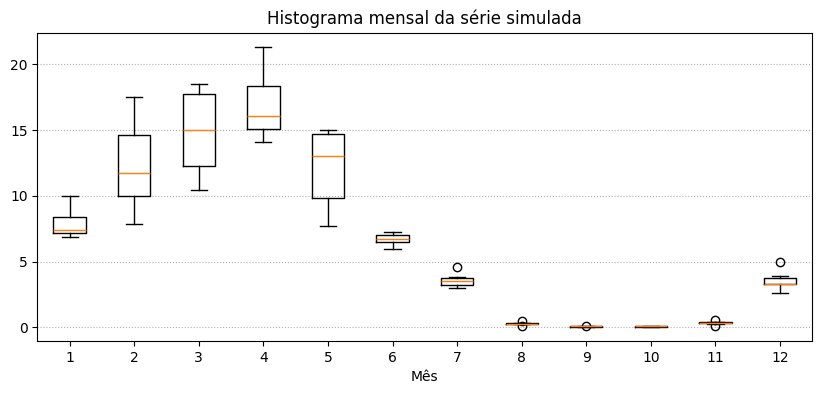

In [12]:
fig, ax = plt.subplots(figsize=(10,4))
plot_data = (df_sim
    .pivot_table(columns=df_sim.index.month, index=df_sim.index.year, values='seasonal')
    .dropna()
)
ax.boxplot(plot_data)
ax.set_xlabel('Mês')
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma mensal da série simulada')
plt.show()

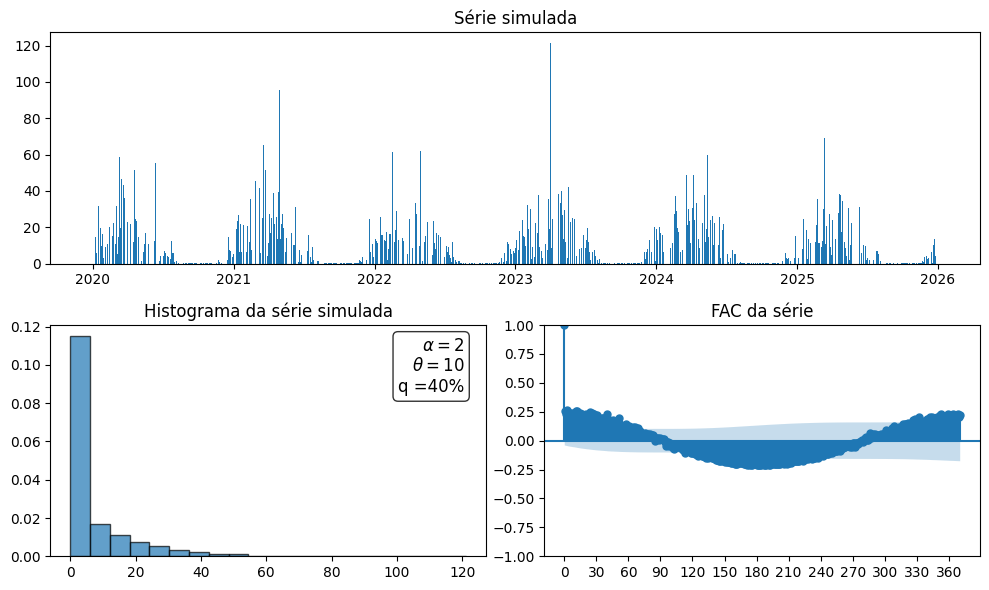

In [13]:
series = df_sim['seasonal']
q_zeros = (series == 0).sum() / len(df_sim)
textstr = f'$\\alpha={alpha}$\n$\\theta={theta}$\nq ={q_zeros:.0%}'

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, :])
ax0.bar(df_sim.index, df_sim['seasonal'], width=1)
ax0.set_title('Série simulada')

ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(df_sim, bins=20, density=True, alpha=0.7, edgecolor='black')
ax1.set_title('Histograma da série simulada')
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
           verticalalignment='top', horizontalalignment='right', bbox=props)

ax2 = fig.add_subplot(gs[1, 1])
lags=370
plot_acf(series.dropna(),lags=lags, ax=ax2, title=f'FAC da série')
ax2.set_xticks(np.arange(0, lags+1, 30))
ax2.set_xticklabels(np.arange(0, lags+1, 30))

fig.tight_layout()
plt.show()

In [14]:
print('Autocorrelação nos últimos lags:')
acf_vals = acf(series, nlags=370, fft=True)
acf_vals[364:]

Autocorrelação nos últimos lags:


array([0.2314482 , 0.16103249, 0.22283169, 0.21108927, 0.2307943 ,
       0.20311289, 0.22487177])

# Simulação Bernoulli-EGPD

## Probabilidade de chuva fixa
$$ 
\begin{align}
    F(y_t|y_{t-1}) &= (1-\pi)*(1-I_{y_t>0}) + \pi*G(y_t|y_{t-1})*I_{y_t>0}, \quad onde \\    
    G(y) &= \mathcal{W}\left\{
                H_\xi\left(\dfrac{y}{\sigma}\right)
            \right\}, \qquad \sigma>0 \qquad com\\
    \mathcal{W}(v) &= v^\kappa, \qquad \kappa>0
\end{align}
$$ 

In [17]:
pi_list = [0.5, 0.65, 0.8]
xi_list = [-0.2, 0, 0.2, 0.49]

sigma = 10 # escala
kappa = 0.5
dates = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
T = len(dates)

results = {}
for xi in xi_list:
    df_sim = pd.DataFrame({'date': dates}).set_index('date')
    
    for pi in pi_list:
        model = naveau(kappa=kappa, sigma=sigma, xi=xi)
        egpd_points = model.rvs(size=T)
        bernoulli_points = rng.binomial(n=1, p=pi, size=T)
        simulated_points = bernoulli_points * egpd_points
        df_sim[f'{pi}'] = simulated_points
    
    results[f'{xi}'] = df_sim
print('Dados simulados com {} observações de {} a {}'.format(
    T, dates[0].strftime('%b %Y'), dates[-1].strftime('%b %Y'))
     )

Dados simulados com 2192 observações de Jan 2020 a Dec 2025


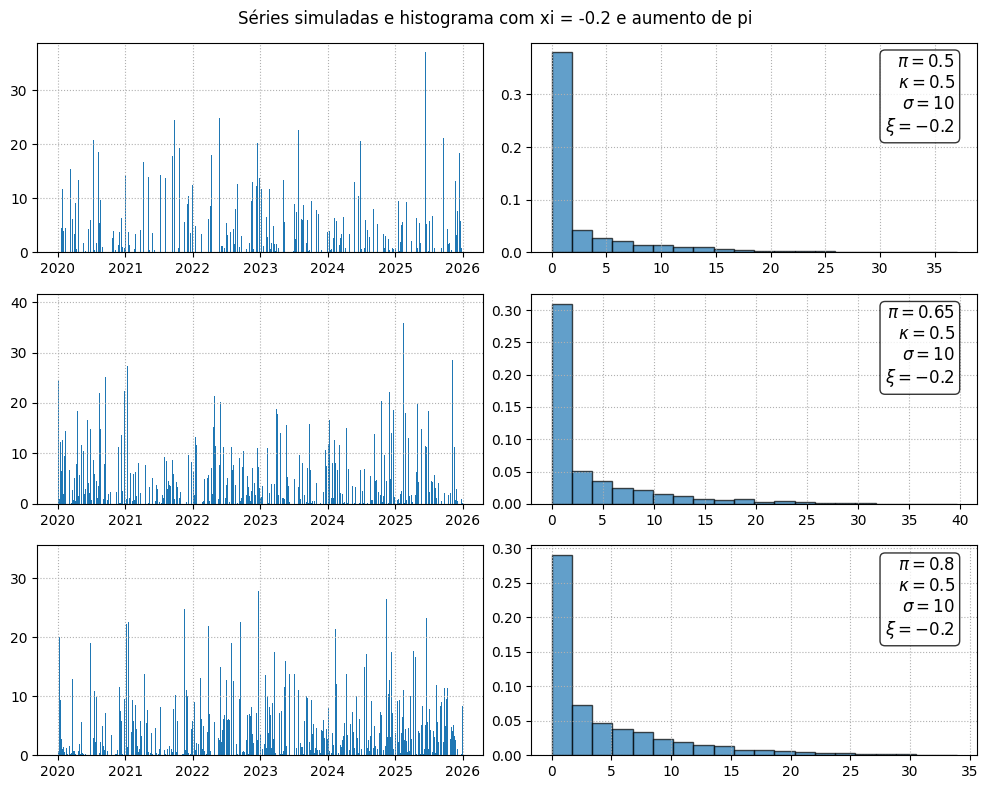

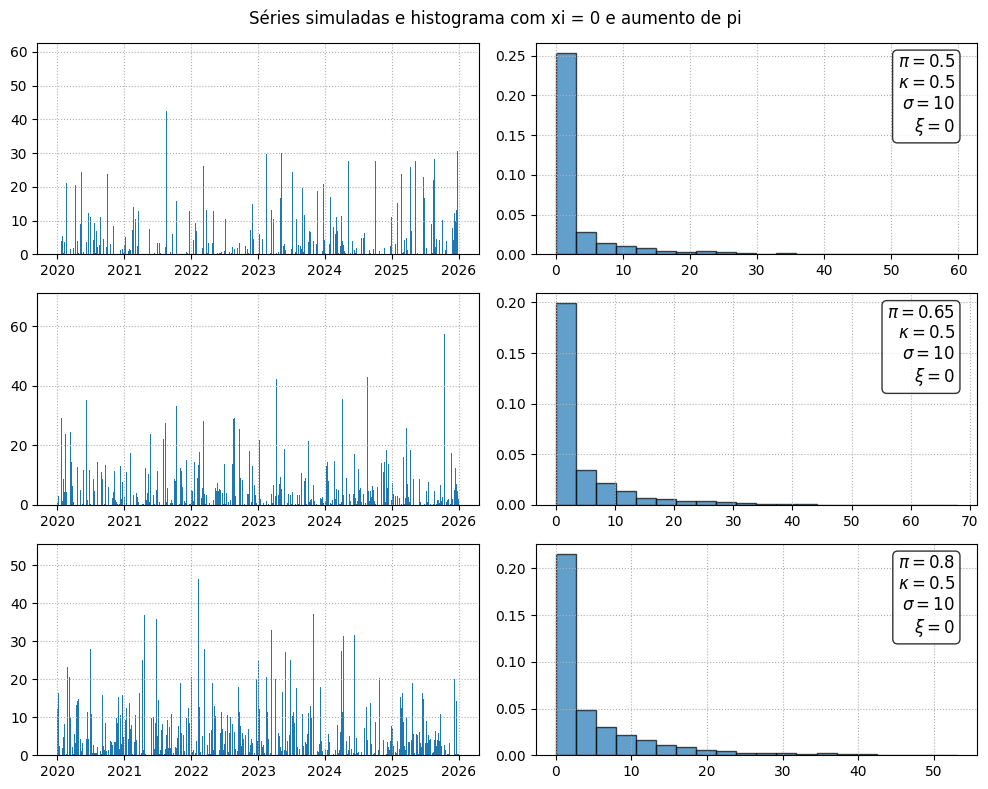

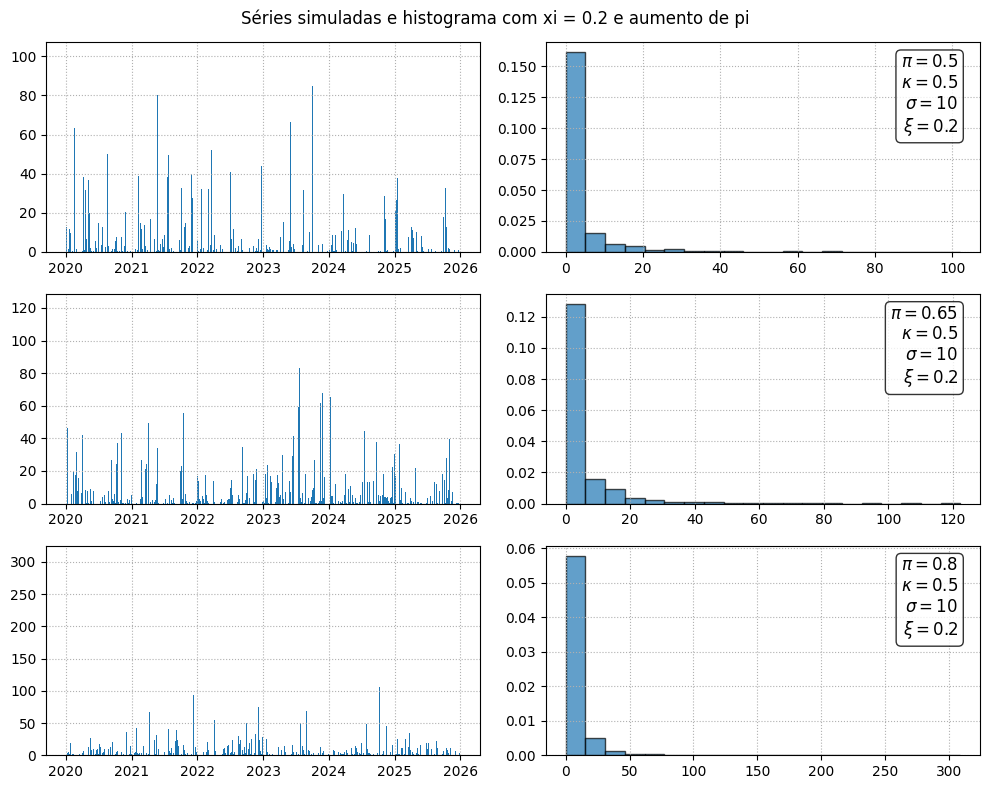

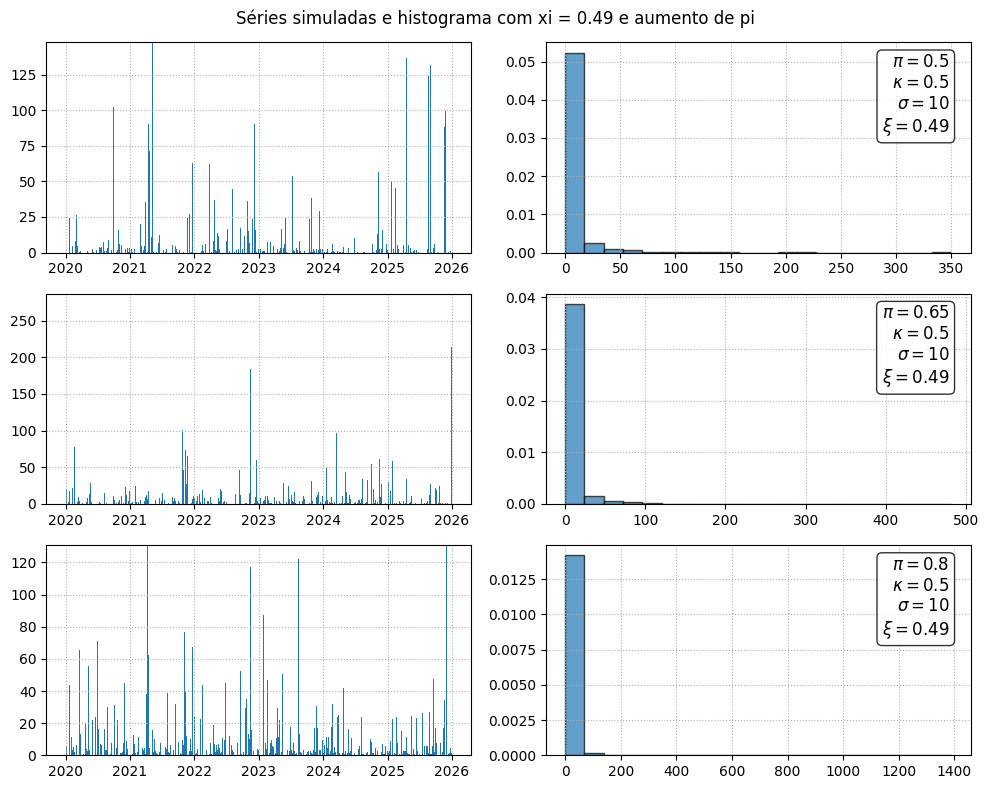

In [16]:
for xi in xi_list:

    fig, ax = plt.subplots(len(pi_list),2,figsize=(10,8))
    
    for i in range(len(pi_list)):
        pi = pi_list[i]
        df_plot = results[f'{xi}'][f'{pi}']
        textstr = f'$\pi={pi}$\n$\\kappa={kappa}$\n$\\sigma={sigma}$\n$\\xi={xi}$'

        if xi==0.49:
            top_lim = results['0.49'].apply(lambda col: col.nlargest(5).iloc[-1])
        ax[i][0].bar(df_plot.index, df_plot, width=1)
        ax[i][0].grid(axis='both', linestyle=':')
        if xi==0.49: ax[i][0].set_ylim(top=top_lim[f'{pi}'])
                
        ax[i][1].hist(df_plot, bins=20, density=True, alpha=0.7, edgecolor='black')
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        ax[i][1].text(0.95, 0.95, textstr, transform=ax[i][1].transAxes, fontsize=12,
                   verticalalignment='top', horizontalalignment='right', bbox=props)
        ax[i][1].grid(axis='both', linestyle=':')
        # if xi==0.49: ax[i][1].set_xlim(right=top_lim[f'{pi}'])
    
    fig.suptitle('Séries simuladas e histograma com xi = {} e aumento de pi'.format(xi))
    fig.tight_layout()
    plt.show()

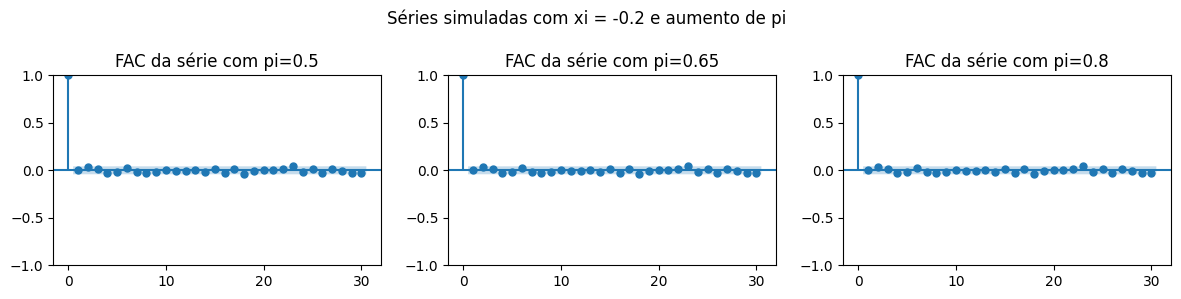

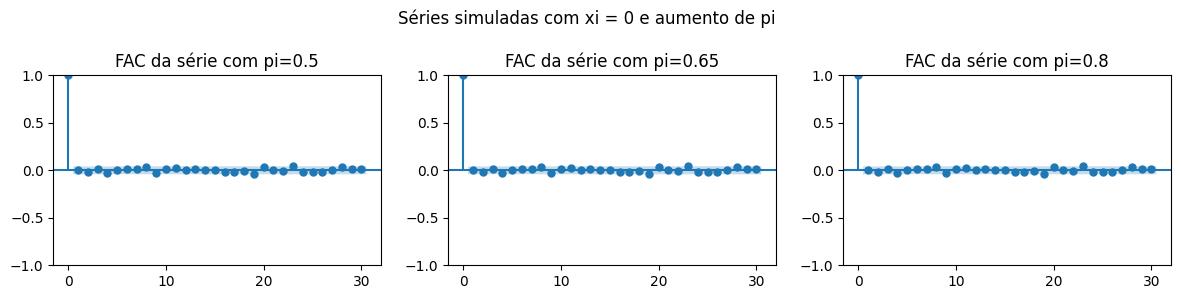

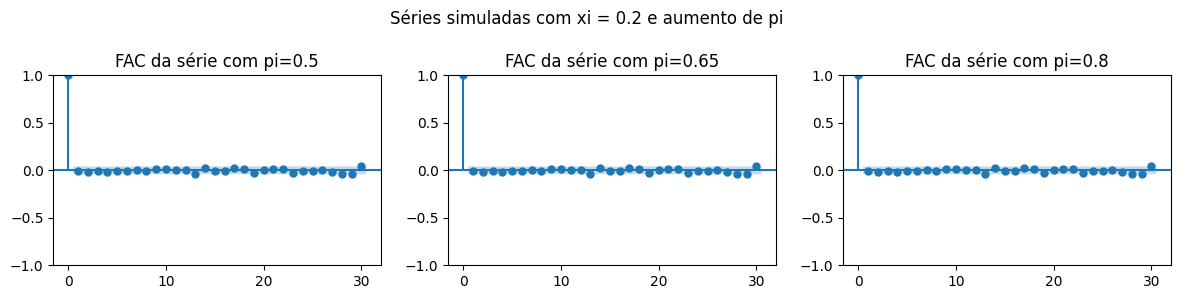

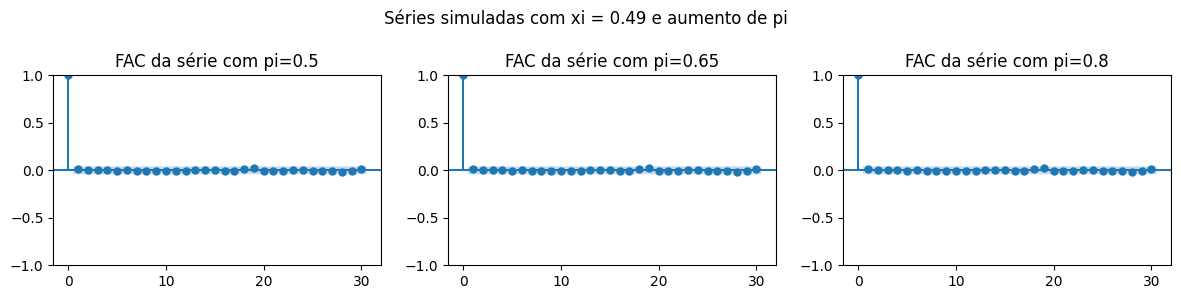

In [17]:
for xi in xi_list:

    fig, ax = plt.subplots(1, len(pi_list),figsize=(12,3))
    for i in range(len(pi_list)):
        lags=30
        df_plot = results[f'{xi}'][f'{pi}']
        plot_acf(df_plot,lags=lags, ax=ax[i], title=f'FAC da série')
        ax[i].set_xticks(np.arange(0, lags+1, 10))
        ax[i].set_xticklabels(np.arange(0, lags+1, 10))
        ax[i].set_title(f'FAC da série com pi={pi_list[i]}')
    
    fig.suptitle('Séries simuladas com xi = {} e aumento de pi'.format(xi))
    fig.tight_layout()
    plt.show()

In [18]:
pi_list = [0.7]
xi_list = [-0.2, 0, 0.2, 0.49]

sigma = 10 # escala
kappa = 0.5
dates = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
T = len(dates)

results = {}
for xi in xi_list:
    df_sim = pd.DataFrame({'date': dates}).set_index('date')
    
    for pi in pi_list:
        model = naveau(kappa=kappa, sigma=sigma, xi=xi)
        egpd_points = model.rvs(size=T)
        bernoulli_points = rng.binomial(n=1, p=pi, size=T)
        simulated_points = bernoulli_points * egpd_points
        df_sim[f'{pi}'] = simulated_points
    
    results[f'{xi}'] = df_sim
print('Dados simulados com {} observações de {} a {}'.format(
    T, dates[0].strftime('%b %Y'), dates[-1].strftime('%b %Y'))
     )

Dados simulados com 2192 observações de Jan 2020 a Dec 2025


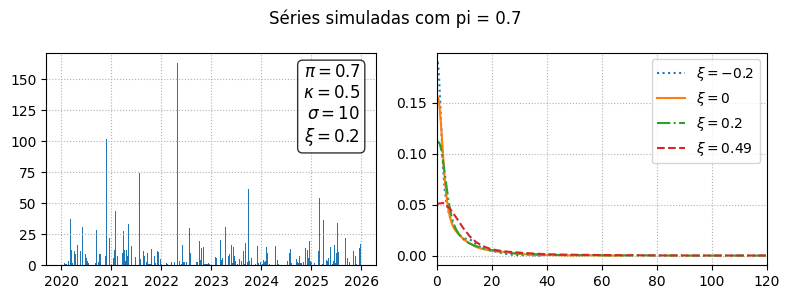

In [23]:
fig, ax = plt.subplots(len(pi_list),2,figsize=(8,3))

i=0
xi = xi_list[2]
pi = pi_list[i]
df_plot = results[f'{xi}'][f'{pi}']
textstr = f'$\pi={pi}$\n$\\kappa={kappa}$\n$\\sigma={sigma}$\n$\\xi={xi}$'
        
top_lim = results['0.49'].apply(lambda col: col.nlargest(5).iloc[-1])
ax[0].bar(df_plot.index, df_plot, width=1)
ax[0].grid(axis='both', linestyle=':')
if xi==0.49: ax[0].set_ylim(top=top_lim[f'{pi}'])
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax[0].text(0.95, 0.95, textstr, transform=ax[0].transAxes, fontsize=12,
           verticalalignment='top', horizontalalignment='right', bbox=props)


ls = [':','-','-.','--']
for xi in xi_list:
    df_plot = results[f'{xi}'][f'{pi}']
    x = np.linspace(0, df_plot.max(), 300)
    kde = gaussian_kde(df_plot)
    ax[1].plot(x, kde(x), label=fr'$\xi={xi}$', linestyle=ls[i])
    i+=1
ax[1].set_xlim(left=0, right=120)
ax[1].grid(axis='both', linestyle=':')
ax[1].legend()
    
fig.suptitle('Séries simuladas com pi = {}'.format(pi))
fig.tight_layout()
plt.show()

## Locação sazonal
$$ 
\begin{align}
    F(y_t|y_{t-1}) &= (1-\pi)*(1-I_{y_t>0}) + \pi*G(y_t|y_{t-1})*I_{y_t>0}, \quad onde \\    
    G(y_t) &= \mathcal{W}\left\{
                H_\xi\left(\dfrac{y_t-\mu_t}{\sigma}\right)
            \right\}, \qquad \sigma>0 \qquad com\\
    \mathcal{W}(v) &= v^\kappa, \qquad \kappa>0 \\
    \mu_t &= a + A \sin\left(\frac{2\pi t}{365}\right)
\end{align}
$$ 

In [26]:
def calculate_lambda(date):
    t = date.dayofyear   
    mu = 10      # média anual (mm)
    A = 5        # amplitude
    t0 = 289     # alinha pico no verão (jan)
    lamb = mu + A * np.sin(2 * np.pi * (t) / 365)  
    return max(lamb, 0.1) # garantia numérica (evita valores muito pequenos)

In [27]:
pi = 0.6
xi=0.2
sigma = 10 # escala
kappa = 0.5

dates = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
T = len(dates)
mu_t = np.array([calculate_lambda(d) for d in dates])


df_sim = pd.DataFrame({'date': dates}).set_index('date')
bernoulli_points = rng.binomial(n=1, p=pi, size=T)
model = naveau(kappa=kappa, sigma=sigma, xi=xi)
egpd_points = mu_t + model.rvs(size=T)

df_sim['seasonal'] = bernoulli_points * egpd_points

print('Dados simulados com {} observações de {} a {}'.format(
    T, dates[0].strftime('%b %Y'), dates[-1].strftime('%b %Y'))
     )

Dados simulados com 2192 observações de Jan 2020 a Dec 2025


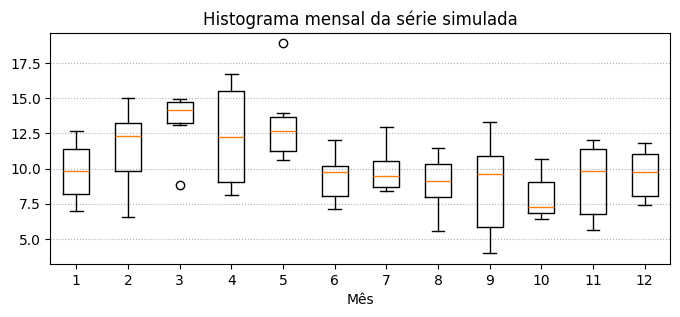

In [28]:
fig, ax = plt.subplots(figsize=(8,3))
plot_data = (df_sim
    .pivot_table(columns=df_sim.index.month, index=df_sim.index.year, values='seasonal')
    .dropna()
)
ax.boxplot(plot_data)
ax.set_xlabel('Mês')
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma mensal da série simulada')
plt.show()

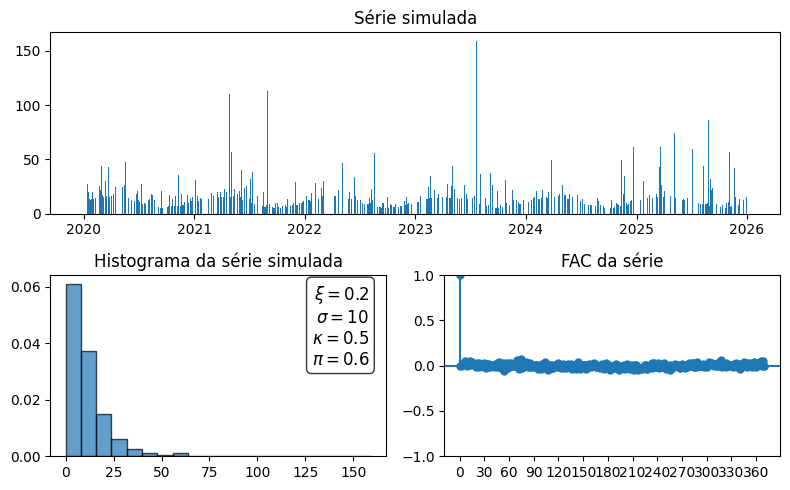

In [29]:
series = df_sim['seasonal']
q_zeros = (series == 0).sum() / len(df_sim)
textstr = f'$\\xi={xi}$\n$\\sigma={sigma}$\n$\\kappa={kappa}$\n$\\pi={pi}$'

fig = plt.figure(figsize=(8, 5))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, :])
ax0.bar(df_sim.index, df_sim['seasonal'], width=0.8)
ax0.set_title('Série simulada')

ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(df_sim, bins=20, density=True, alpha=0.7, edgecolor='black')
ax1.set_title('Histograma da série simulada')
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
           verticalalignment='top', horizontalalignment='right', bbox=props)

ax2 = fig.add_subplot(gs[1, 1])
lags=370
plot_acf(series.dropna(),lags=lags, ax=ax2, title=f'FAC da série')
ax2.set_xticks(np.arange(0, lags+1, 30))
ax2.set_xticklabels(np.arange(0, lags+1, 30))

fig.tight_layout()
plt.show()

In [30]:
print('Autocorrelação nos últimos lags:')
acf_vals = acf(series, nlags=370, fft=True)
acf_vals[364:]

Autocorrelação nos últimos lags:


array([ 0.00292857,  0.02129989,  0.05508615, -0.00789417,  0.05410672,
       -0.0087058 ,  0.0016587 ])

## Escala sazonal
$$ 
\begin{align}
    F(y_t|y_{t-1}) &= (1-\pi)*(1-I_{y_t>0}) + \pi*G(y_t|y_{t-1})*I_{y_t>0}, \quad onde \\    
    G(y_t) &= \mathcal{W}\left\{
                H_\xi\left(\dfrac{y_t}{\sigma_t}\right)
            \right\}, \qquad \sigma>0 \qquad com\\
    \mathcal{W}(v) &= v^\kappa, \qquad \kappa>0 \\
    \sigma_t &= a + A \sin\left(\frac{2\pi t}{365}\right)
\end{align}
$$ 

In [31]:
def calculate_lambda(date):
    t = date.dayofyear   
    mu = 10      # média anual (mm)
    A = 5        # amplitude
    t0 = 289     # alinha pico no verão (jan)
    lamb = mu + A * np.sin(2 * np.pi * (t) / 365)  
    return max(lamb, 0.1) # garantia numérica (evita valores muito pequenos)

In [37]:
pi = 0.6
xi=0.2
kappa = 0.8

dates = pd.date_range(start='2010-01-01', end='2025-12-31', freq='D')
T = len(dates)
sigma_t = np.array([calculate_lambda(d) for d in dates])


df_sim = pd.DataFrame({'date': dates}).set_index('date')
bernoulli_points = rng.binomial(n=1, p=pi, size=T)
model = naveau(kappa=kappa, sigma=1, xi=xi)
egpd_points = sigma_t * model.rvs(size=T)

df_sim['seasonal'] = bernoulli_points * egpd_points

print('Dados simulados com {} observações de {} a {}'.format(
    T, dates[0].strftime('%b %Y'), dates[-1].strftime('%b %Y'))
     )

Dados simulados com 5844 observações de Jan 2010 a Dec 2025


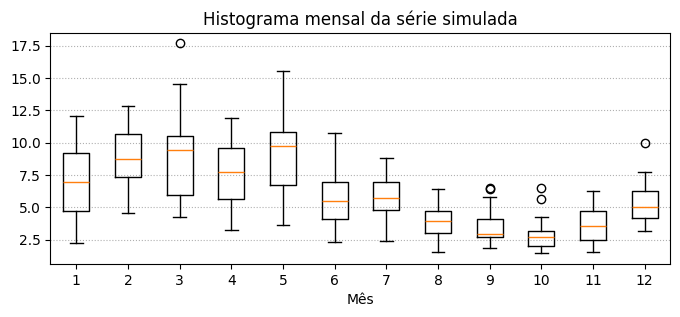

In [38]:
fig, ax = plt.subplots(figsize=(8,3))
plot_data = (df_sim
    .pivot_table(columns=df_sim.index.month, index=df_sim.index.year, values='seasonal')
    .dropna()
)
ax.boxplot(plot_data)
ax.set_xlabel('Mês')
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma mensal da série simulada')
plt.show()

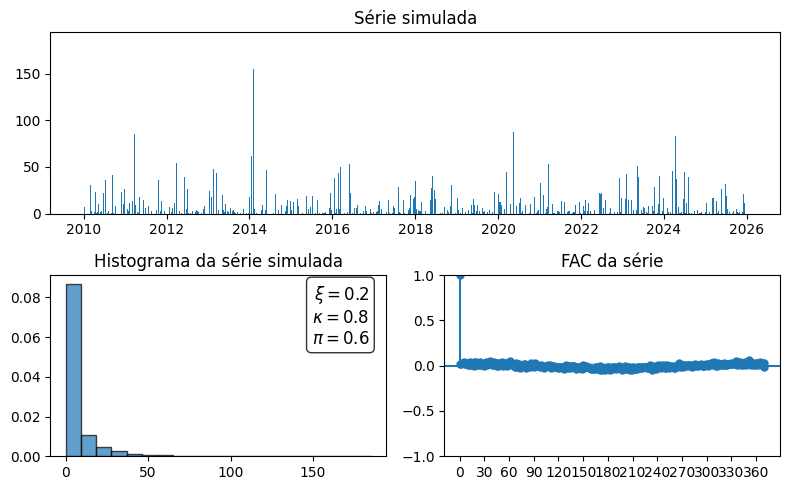

In [39]:
series = df_sim['seasonal']
q_zeros = (series == 0).sum() / len(df_sim)
textstr = f'$\\xi={xi}$\n$\\kappa={kappa}$\n$\\pi={pi}$'

fig = plt.figure(figsize=(8, 5))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, :])
ax0.bar(df_sim.index, df_sim['seasonal'], width=0.8)
ax0.set_title('Série simulada')

ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(df_sim, bins=20, density=True, alpha=0.7, edgecolor='black')
ax1.set_title('Histograma da série simulada')
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
           verticalalignment='top', horizontalalignment='right', bbox=props)

ax2 = fig.add_subplot(gs[1, 1])
lags=370
plot_acf(series.dropna(),lags=lags, ax=ax2, title=f'FAC da série')
ax2.set_xticks(np.arange(0, lags+1, 30))
ax2.set_xticklabels(np.arange(0, lags+1, 30))

fig.tight_layout()
plt.show()

In [40]:
print('Autocorrelação nos últimos lags:')
acf_vals = acf(series, nlags=370, fft=True)
acf_vals[364:]

Autocorrelação nos últimos lags:


array([ 0.01804319,  0.03967596,  0.01937438,  0.01257941,  0.02586914,
       -0.01488248,  0.02883833])